Տարածության մեջ տրված է ուղղորդ կոր՝

$$
\vec r(u) = (u^2 + 1)\,\vec i + (u^3 + 2)\,\vec j + (2u - 3)\,\vec k
$$

որտեղ

$$
0 \le u \le 10, \qquad -\frac{\pi}{3} \le v \le \frac{\pi}{3}.
$$

Տուփաձև մակերևույթը կազմված է երեք նիստերից, այսինքն՝ $K=3$, $k=1,2,3$,
իսկ անկյունային տեղաշարժը՝

$$
\varphi = \frac{\pi}{K}.
$$

$R_0(u)$-ն լայնական հատույթի շառավղի փոփոխման ֆունկցիան է։


### ա) Հաստատուն շառավիղ
$$
R_0(u)=5
$$

### բ) Փոփոխական շառավիղ
$$
R_0(u)=\frac{u^3+2}{u^2+1}
$$
**Պահանջվում է** կառուցել տուփաձև մակերևույթի երեք նիստերի
պարամետրական հավասարումները՝

$$
\rho_1(u,v), \quad \rho_2(u,v), \quad \rho_3(u,v),
$$

ինչպես նաև սահմանել տուփաձև մակերևույթը որպես այդ նիստերի միավորում՝

$$
\mathcal{S} = \rho_1(u,v) \cup \rho_2(u,v) \cup \rho_3(u,v),
$$

և իրականացնել դրանց գրաֆիկական պատկերումը։

### ա) Հաստատուն շառավիղ
$$
R_0(u)=5
$$


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import sympy as sp

In [12]:
u, v = sp.symbols('u v')

r_u = sp.Matrix([u**2 + 1, u**3 + 2, 2*u - 3])

r_prime = sp.diff(r_u, u)
r_double_prime = sp.diff(r_prime, u)

cross_rprime_rdoubleprime = r_prime.cross(r_double_prime)
norm_cross = sp.sqrt(cross_rprime_rdoubleprime.dot(cross_rprime_rdoubleprime))
g0_u = cross_rprime_rdoubleprime / norm_cross

numerator_e0 = cross_rprime_rdoubleprime.cross(r_prime)
norm_r_prime = sp.sqrt(r_prime.dot(r_prime))
e0_u = numerator_e0 / (norm_cross * norm_r_prime)

In [13]:
phi = sp.pi / 3
R0 = 5


rho1 = r_u + (R0 / (2*sp.cos(v))) * (
    sp.cos(v + 2*phi*1) * e0_u + sp.sin(v + 2*phi*1) * g0_u
)

rho2 = r_u + (R0 / (2*sp.cos(v))) * (
    sp.cos(v + 2*phi*2) * e0_u + sp.sin(v + 2*phi*2) * g0_u
)

rho3 = r_u + (R0 / (2*sp.cos(v))) * (
    sp.cos(v + 2*phi*3) * e0_u + sp.sin(v + 2*phi*3) * g0_u
)

In [14]:
print("r(u) =")
sp.pprint(r_u)
print("\n r'(u) =")
sp.pprint(r_prime)
print("\n r''(u) =")
sp.pprint(r_double_prime)

print("\n g₀(u) =")
sp.pprint(g0_u)

print("\n e₀(u) =")
sp.pprint(e0_u)

print("\nρ₁(u,v) =")
sp.pprint(rho1)

print("\nρ₂(u,v) =")
sp.pprint(rho2)

print("\nρ₃(u,v) =")
sp.pprint(rho3)

r(u) =
⎡ 2     ⎤
⎢u  + 1 ⎥
⎢       ⎥
⎢ 3     ⎥
⎢u  + 2 ⎥
⎢       ⎥
⎣2⋅u - 3⎦

 r'(u) =
⎡2⋅u ⎤
⎢    ⎥
⎢   2⎥
⎢3⋅u ⎥
⎢    ⎥
⎣ 2  ⎦

 r''(u) =
⎡ 2 ⎤
⎢   ⎥
⎢6⋅u⎥
⎢   ⎥
⎣ 0 ⎦

 g₀(u) =
⎡         -12⋅u          ⎤
⎢────────────────────────⎥
⎢   _____________________⎥
⎢  ╱     4        2      ⎥
⎢╲╱  36⋅u  + 144⋅u  + 16 ⎥
⎢                        ⎥
⎢           4            ⎥
⎢────────────────────────⎥
⎢   _____________________⎥
⎢  ╱     4        2      ⎥
⎢╲╱  36⋅u  + 144⋅u  + 16 ⎥
⎢                        ⎥
⎢             2          ⎥
⎢          6⋅u           ⎥
⎢────────────────────────⎥
⎢   _____________________⎥
⎢  ╱     4        2      ⎥
⎣╲╱  36⋅u  + 144⋅u  + 16 ⎦

 e₀(u) =
⎡                          4                  ⎤
⎢                  8 - 18⋅u                   ⎥
⎢─────────────────────────────────────────────⎥
⎢   _________________    _____________________⎥
⎢  ╱    4      2        ╱     4        2      ⎥
⎢╲╱  9⋅u  + 4⋅u  + 4 ⋅╲╱  36⋅u  + 144⋅u  + 16 ⎥
⎢                                   

In [15]:
rho1_x = sp.lambdify((u, v), rho1[0], 'numpy')
rho1_y = sp.lambdify((u, v), rho1[1], 'numpy')
rho1_z = sp.lambdify((u, v), rho1[2], 'numpy')

rho2_x = sp.lambdify((u, v), rho2[0], 'numpy')
rho2_y = sp.lambdify((u, v), rho2[1], 'numpy')
rho2_z = sp.lambdify((u, v), rho2[2], 'numpy')

rho3_x = sp.lambdify((u, v), rho3[0], 'numpy')
rho3_y = sp.lambdify((u, v), rho3[1], 'numpy')
rho3_z = sp.lambdify((u, v), rho3[2], 'numpy')


u_vals = np.linspace(0, 10, 120)
v_vals = np.linspace(-np.pi/3, np.pi/3, 120)
U, V = np.meshgrid(u_vals, v_vals)

X1, Y1, Z1 = rho1_x(U, V), rho1_y(U, V), rho1_z(U, V)
X2, Y2, Z2 = rho2_x(U, V), rho2_y(U, V), rho2_z(U, V)
X3, Y3, Z3 = rho3_x(U, V), rho3_y(U, V), rho3_z(U, V)

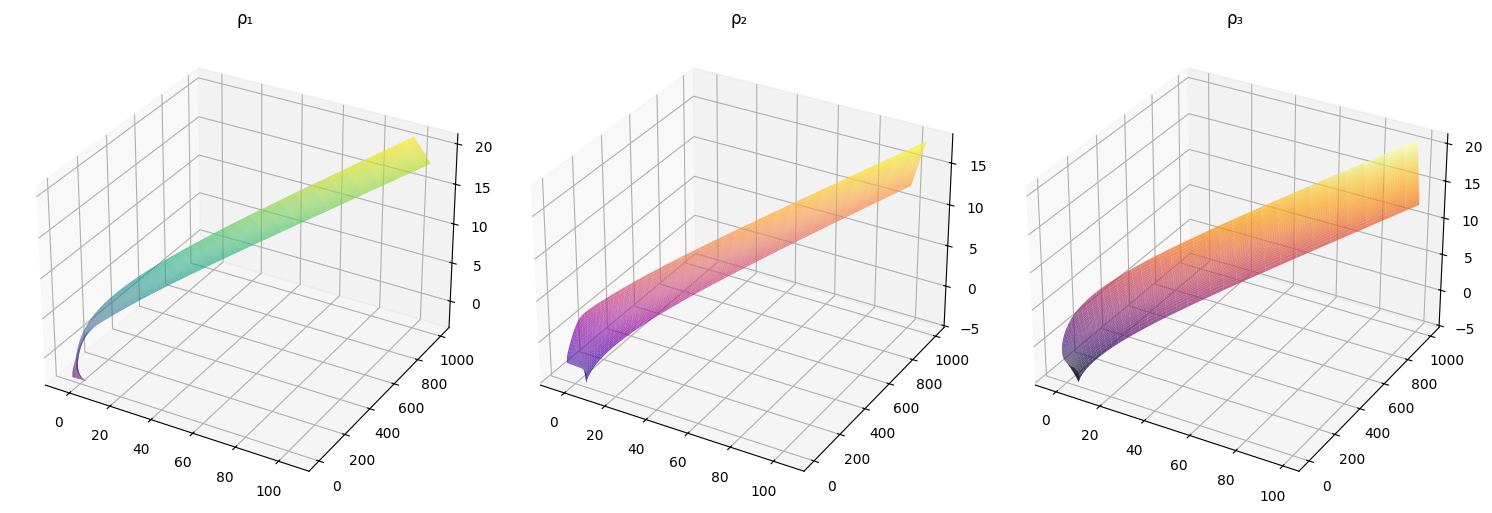

In [16]:
fig = plt.figure(figsize=(15, 5))

ax1 = fig.add_subplot(131, projection='3d')
ax1.plot_surface(X1, Y1, Z1, alpha=0.7, cmap='viridis')
ax1.set_title('ρ₁')

ax2 = fig.add_subplot(132, projection='3d')
ax2.plot_surface(X2, Y2, Z2, alpha=0.7, cmap='plasma')
ax2.set_title('ρ₂')

ax3 = fig.add_subplot(133, projection='3d')
ax3.plot_surface(X3, Y3, Z3, alpha=0.7, cmap='inferno')
ax3.set_title('ρ₃')

plt.tight_layout()
plt.show()

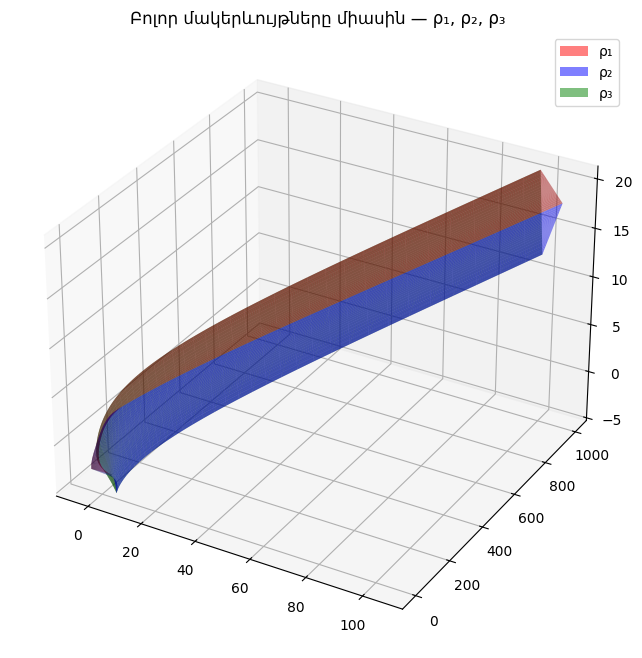

In [17]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.set_title('Բոլոր մակերևույթները միասին — ρ₁, ρ₂, ρ₃')

ax.plot_surface(X1, Y1, Z1, alpha=0.5, color='red')
ax.plot_surface(X2, Y2, Z2, alpha=0.5, color='blue')
ax.plot_surface(X3, Y3, Z3, alpha=0.5, color='green')

legend_elements = [
    Patch(facecolor='red', alpha=0.5, label='ρ₁'),
    Patch(facecolor='blue', alpha=0.5, label='ρ₂'),
    Patch(facecolor='green', alpha=0.5, label='ρ₃')
]
ax.legend(handles=legend_elements)

plt.show()

### բ) Փոփոխական շառավիղ
$$
R_0(u)=\frac{u^3+2}{u^2+1}
$$

In [19]:
phi = sp.pi / 3
R0 = (u**3 + 2) / (u**2 + 1)


rho1 = r_u + (R0 / (2*sp.cos(v))) * (
    sp.cos(v + 2*phi*1) * e0_u + sp.sin(v + 2*phi*1) * g0_u
)

rho2 = r_u + (R0 / (2*sp.cos(v))) * (
    sp.cos(v + 2*phi*2) * e0_u + sp.sin(v + 2*phi*2) * g0_u
)

rho3 = r_u + (R0 / (2*sp.cos(v))) * (
    sp.cos(v + 2*phi*3) * e0_u + sp.sin(v + 2*phi*3) * g0_u
)

In [20]:
print("r(u) =")
sp.pprint(r_u)
print("\n r'(u) =")
sp.pprint(r_prime)
print("\n r''(u) =")
sp.pprint(r_double_prime)

print("\n g₀(u) =")
sp.pprint(g0_u)

print("\n e₀(u) =")
sp.pprint(e0_u)

print("\nρ₁(u,v) =")
sp.pprint(rho1)

print("\nρ₂(u,v) =")
sp.pprint(rho2)

print("\nρ₃(u,v) =")
sp.pprint(rho3)

r(u) =
⎡ 2     ⎤
⎢u  + 1 ⎥
⎢       ⎥
⎢ 3     ⎥
⎢u  + 2 ⎥
⎢       ⎥
⎣2⋅u - 3⎦

 r'(u) =
⎡2⋅u ⎤
⎢    ⎥
⎢   2⎥
⎢3⋅u ⎥
⎢    ⎥
⎣ 2  ⎦

 r''(u) =
⎡ 2 ⎤
⎢   ⎥
⎢6⋅u⎥
⎢   ⎥
⎣ 0 ⎦

 g₀(u) =
⎡         -12⋅u          ⎤
⎢────────────────────────⎥
⎢   _____________________⎥
⎢  ╱     4        2      ⎥
⎢╲╱  36⋅u  + 144⋅u  + 16 ⎥
⎢                        ⎥
⎢           4            ⎥
⎢────────────────────────⎥
⎢   _____________________⎥
⎢  ╱     4        2      ⎥
⎢╲╱  36⋅u  + 144⋅u  + 16 ⎥
⎢                        ⎥
⎢             2          ⎥
⎢          6⋅u           ⎥
⎢────────────────────────⎥
⎢   _____________________⎥
⎢  ╱     4        2      ⎥
⎣╲╱  36⋅u  + 144⋅u  + 16 ⎦

 e₀(u) =
⎡                          4                  ⎤
⎢                  8 - 18⋅u                   ⎥
⎢─────────────────────────────────────────────⎥
⎢   _________________    _____________________⎥
⎢  ╱    4      2        ╱     4        2      ⎥
⎢╲╱  9⋅u  + 4⋅u  + 4 ⋅╲╱  36⋅u  + 144⋅u  + 16 ⎥
⎢                                   

In [21]:
rho1_x = sp.lambdify((u, v), rho1[0], 'numpy')
rho1_y = sp.lambdify((u, v), rho1[1], 'numpy')
rho1_z = sp.lambdify((u, v), rho1[2], 'numpy')

rho2_x = sp.lambdify((u, v), rho2[0], 'numpy')
rho2_y = sp.lambdify((u, v), rho2[1], 'numpy')
rho2_z = sp.lambdify((u, v), rho2[2], 'numpy')

rho3_x = sp.lambdify((u, v), rho3[0], 'numpy')
rho3_y = sp.lambdify((u, v), rho3[1], 'numpy')
rho3_z = sp.lambdify((u, v), rho3[2], 'numpy')


u_vals = np.linspace(0, 10, 120)
v_vals = np.linspace(-np.pi/3, np.pi/3, 120)
U, V = np.meshgrid(u_vals, v_vals)

X1, Y1, Z1 = rho1_x(U, V), rho1_y(U, V), rho1_z(U, V)
X2, Y2, Z2 = rho2_x(U, V), rho2_y(U, V), rho2_z(U, V)
X3, Y3, Z3 = rho3_x(U, V), rho3_y(U, V), rho3_z(U, V)

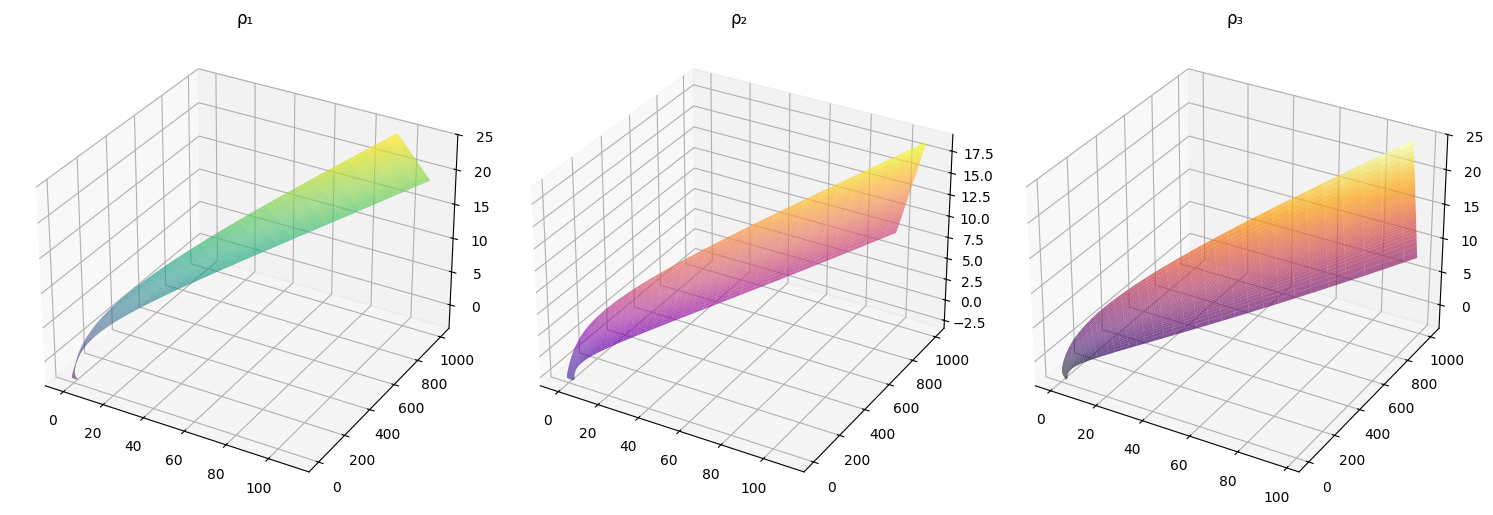

In [22]:
fig = plt.figure(figsize=(15, 5))

ax1 = fig.add_subplot(131, projection='3d')
ax1.plot_surface(X1, Y1, Z1, alpha=0.7, cmap='viridis')
ax1.set_title('ρ₁')

ax2 = fig.add_subplot(132, projection='3d')
ax2.plot_surface(X2, Y2, Z2, alpha=0.7, cmap='plasma')
ax2.set_title('ρ₂')

ax3 = fig.add_subplot(133, projection='3d')
ax3.plot_surface(X3, Y3, Z3, alpha=0.7, cmap='inferno')
ax3.set_title('ρ₃')

plt.tight_layout()
plt.show()

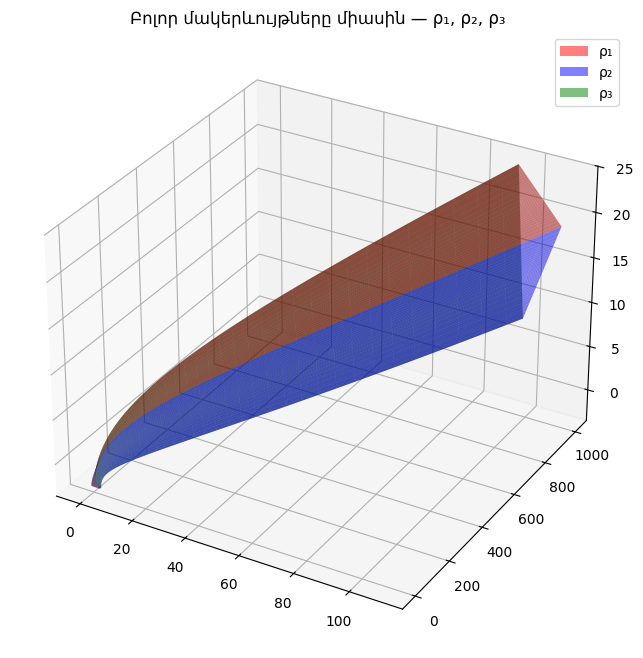

In [23]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.set_title('Բոլոր մակերևույթները միասին — ρ₁, ρ₂, ρ₃')

ax.plot_surface(X1, Y1, Z1, alpha=0.5, color='red')
ax.plot_surface(X2, Y2, Z2, alpha=0.5, color='blue')
ax.plot_surface(X3, Y3, Z3, alpha=0.5, color='green')

legend_elements = [
    Patch(facecolor='red', alpha=0.5, label='ρ₁'),
    Patch(facecolor='blue', alpha=0.5, label='ρ₂'),
    Patch(facecolor='green', alpha=0.5, label='ρ₃')
]
ax.legend(handles=legend_elements)
plt.show()